Deadlock Detected Example:


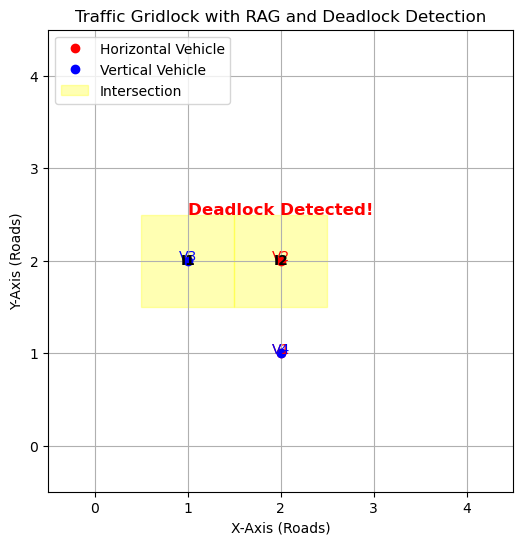

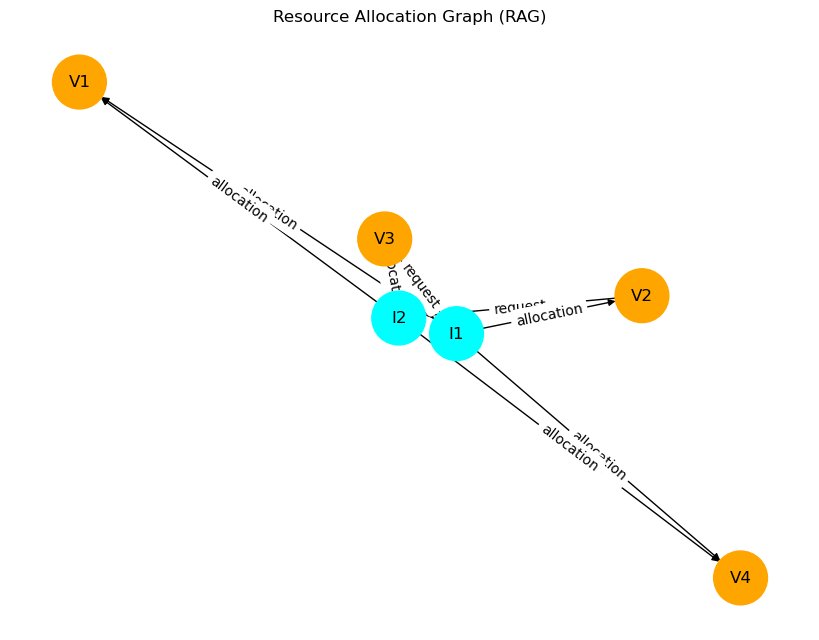

In [1]:
# Detection of deadlock

#By Using Cycle Detection

import matplotlib.pyplot as plt
import networkx as nx

def detect_deadlock_rag(rag):
    try:
        cycle = nx.find_cycle(rag, orientation='original')
        return cycle
    except nx.NetworkXNoCycle:
        return None

def create_rag(horizontal_vehicles, vertical_vehicles, intersections):
    rag = nx.DiGraph()

    for i, vehicle in enumerate(horizontal_vehicles + vertical_vehicles):
        rag.add_node(f"V{i+1}", type="process") 
    for i, intersection in enumerate(intersections):
        rag.add_node(f"I{i+1}", type="resource") 

    for i, (vx, vy) in enumerate(horizontal_vehicles):
        for j, (ix, iy) in enumerate(intersections):
            if (vx, vy) == (ix, iy):  
                rag.add_edge(f"V{i+1}", f"I{j+1}", type="request")
            else:
                rag.add_edge(f"I{j+1}", f"V{i+1}", type="allocation")
    
    for i, (vx, vy) in enumerate(vertical_vehicles, start=len(horizontal_vehicles)):
        for j, (ix, iy) in enumerate(intersections):
            if (vx, vy) == (ix, iy):
                rag.add_edge(f"V{i+1}", f"I{j+1}", type="request")
            else:
                rag.add_edge(f"I{j+1}", f"V{i+1}", type="allocation")

    return rag

def simulate_traffic_with_rag(horizontal_vehicles, vertical_vehicles, intersections):
    rag = create_rag(horizontal_vehicles, vertical_vehicles, intersections)


    deadlock_cycle = detect_deadlock_rag(rag)


    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-0.5, 5 - 0.5)
    ax.set_ylim(-0.5, 5 - 0.5)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True)

    for i, (vx, vy) in enumerate(horizontal_vehicles):
        ax.plot(vx, vy, 'ro', label='Horizontal Vehicle' if i == 0 else "")  # Red circles
        ax.text(vx, vy, f"V{i+1}", color='red', ha='center')
    for i, (vx, vy) in enumerate(vertical_vehicles, start=len(horizontal_vehicles)):
        ax.plot(vx, vy, 'bo', label='Vertical Vehicle' if i == len(horizontal_vehicles) else "")  # Blue circles
        ax.text(vx, vy, f"V{i+1}", color='blue', ha='center')

    for i, (ix, iy) in enumerate(intersections):
        ax.add_patch(plt.Rectangle((ix - 0.5, iy - 0.5), 1, 1, color='yellow', alpha=0.3, label='Intersection' if i == 0 else ""))
        ax.text(ix, iy, f"I{i+1}", color='black', ha='center', va='center', weight='bold')

    if deadlock_cycle:
        ax.text(2, 2.5, 'Deadlock Detected!', color='red', ha='center', fontsize=12, weight='bold')
    else:
        ax.text(2, 2.5, 'No Deadlock', color='green', ha='center', fontsize=12, weight='bold')

    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))
    ax.legend(unique_handles_labels.values(), unique_handles_labels.keys(), loc='upper left')

    ax.set_title('Traffic Gridlock with RAG and Deadlock Detection')
    ax.set_xlabel('X-Axis (Roads)')
    ax.set_ylabel('Y-Axis (Roads)')

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(rag)
    colors = ['cyan' if rag.nodes[node]['type'] == 'resource' else 'orange' for node in rag.nodes()]
    nx.draw(rag, pos, with_labels=True, node_color=colors, edge_color='black', node_size=1500)
    edge_labels = nx.get_edge_attributes(rag, 'type')
    nx.draw_networkx_edge_labels(rag, pos, edge_labels=edge_labels)
    plt.title("Resource Allocation Graph (RAG)")

    plt.show()

horizontal_vehicles_deadlock = [(2, 1), (2, 2)]  
vertical_vehicles_deadlock = [(1, 2),(2,1)]
intersections_deadlock = [(1,2),(2,2)]  


print("Deadlock Detected Example:")
simulate_traffic_with_rag(horizontal_vehicles_deadlock, vertical_vehicles_deadlock, intersections_deadlock)

New Deadlock Example with Prevention:


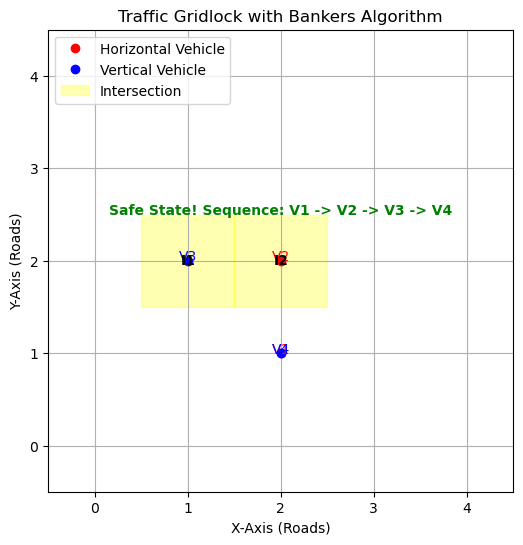

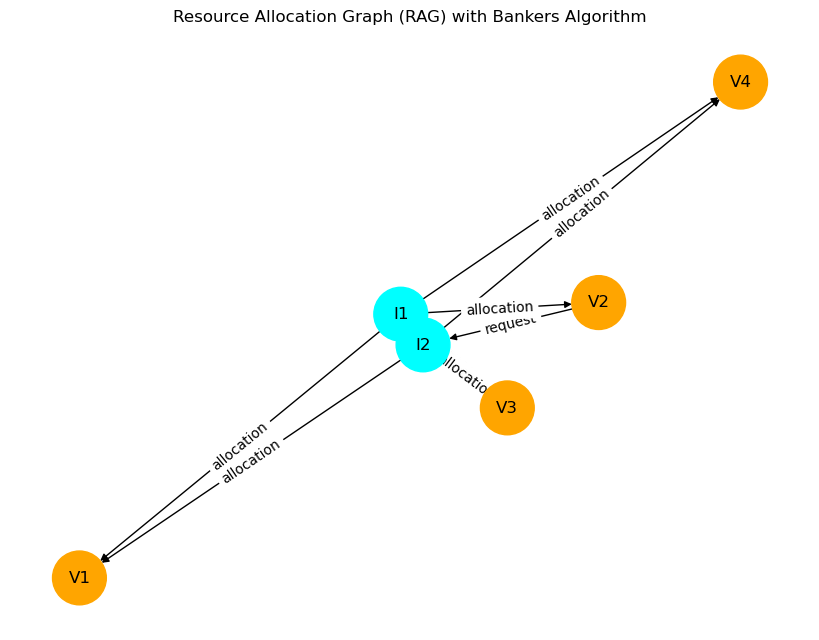

In [2]:
# Prevention of Deadlock

#By using Bankers Algorithm

import matplotlib.pyplot as plt
import networkx as nx

def is_safe(allocation, max_need, available):

    n_processes = len(allocation)
    n_resources = len(available)
    work = available[:]
    finish = [False] * n_processes
    safe_sequence = []

    while len(safe_sequence) < n_processes:
        found = False
        for i in range(n_processes):
            if not finish[i]:
                if all(max_need[i][j] - allocation[i][j] <= work[j] for j in range(n_resources)):
                    for j in range(n_resources):
                        work[j] += allocation[i][j]
                    finish[i] = True
                    safe_sequence.append(i)
                    found = True
                    break
        if not found:
            return False, []

    return True, safe_sequence

def create_rag_with_bankers(horizontal_vehicles, vertical_vehicles, intersections):
    allocation = [[0] * len(intersections) for _ in range(len(horizontal_vehicles + vertical_vehicles))]
    max_need = [[1] * len(intersections) for _ in range(len(horizontal_vehicles + vertical_vehicles))]
    available = [1] * len(intersections)

    for i, vehicle in enumerate(horizontal_vehicles + vertical_vehicles):
        for j, intersection in enumerate(intersections):
            allocation[i][j] = 1 if vehicle == intersection else 0

    is_safe_state, safe_sequence = is_safe(allocation, max_need, available)

    rag = nx.DiGraph()

    for i, _ in enumerate(horizontal_vehicles + vertical_vehicles):
        rag.add_node(f"V{i+1}", type="process")
    for j, _ in enumerate(intersections):
        rag.add_node(f"I{j+1}", type="resource")

    for i, vehicle in enumerate(horizontal_vehicles + vertical_vehicles):
        for j, intersection in enumerate(intersections):
            if vehicle == intersection:
                rag.add_edge(f"V{i+1}", f"I{j+1}", type="request")
            else:
                rag.add_edge(f"I{j+1}", f"V{i+1}", type="allocation")

    return rag, is_safe_state, safe_sequence

def simulate_traffic_with_bankers(horizontal_vehicles, vertical_vehicles, intersections):
    rag, is_safe_state, safe_sequence = create_rag_with_bankers(horizontal_vehicles, vertical_vehicles, intersections)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-0.5, 5 - 0.5)
    ax.set_ylim(-0.5, 5 - 0.5)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True)

    for i, (vx, vy) in enumerate(horizontal_vehicles):
        ax.plot(vx, vy, 'ro', label='Horizontal Vehicle' if i == 0 else "")  # Red circles
        ax.text(vx, vy, f"V{i+1}", color='red', ha='center')
    for i, (vx, vy) in enumerate(vertical_vehicles, start=len(horizontal_vehicles)):
        ax.plot(vx, vy, 'bo', label='Vertical Vehicle' if i == len(horizontal_vehicles) else "")  # Blue circles
        ax.text(vx, vy, f"V{i+1}", color='blue', ha='center')

    for i, (ix, iy) in enumerate(intersections):
        ax.add_patch(plt.Rectangle((ix - 0.5, iy - 0.5), 1, 1, color='yellow', alpha=0.3, label='Intersection' if i == 0 else ""))
        ax.text(ix, iy, f"I{i+1}", color='black', ha='center', va='center', weight='bold')

    if is_safe_state:
        ax.text(2, 2.5, f"Safe State! Sequence: {' -> '.join(f'V{p+1}' for p in safe_sequence)}",
                color='green', ha='center', fontsize=10, weight='bold')
    else:
        ax.text(2, 2.5, 'Deadlock Detected! Unsafe State! Request Denied.', color='red', ha='center', fontsize=12, weight='bold')

    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))
    ax.legend(unique_handles_labels.values(), unique_handles_labels.keys(), loc='upper left')

    ax.set_title('Traffic Gridlock with Bankers Algorithm')
    ax.set_xlabel('X-Axis (Roads)')
    ax.set_ylabel('Y-Axis (Roads)')

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(rag)
    colors = ['cyan' if rag.nodes[node]['type'] == 'resource' else 'orange' for node in rag.nodes()]
    nx.draw(rag, pos, with_labels=True, node_color=colors, edge_color='black', node_size=1500)
    edge_labels = nx.get_edge_attributes(rag, 'type')
    nx.draw_networkx_edge_labels(rag, pos, edge_labels=edge_labels)
    plt.title("Resource Allocation Graph (RAG) with Bankers Algorithm")

    plt.show()


horizontal_vehicles_new_deadlock = [(2, 1), (2, 2)]  
vertical_vehicles_new_deadlock = [(1, 2),(2,1)]  
intersections_new_deadlock = [(1,2),(2,2)]  

print("New Deadlock Example with Prevention:")
simulate_traffic_with_bankers(horizontal_vehicles_new_deadlock, vertical_vehicles_new_deadlock, intersections_new_deadlock)